In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
import warnings 

warnings.filterwarnings("ignore")


In [6]:
pip install matplotlib 

Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install plotly seaborn 

Note: you may need to restart the kernel to use updated packages.


In [8]:
df = pd.read_csv(r"EasyVisa.csv")

In [9]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [10]:
df.columns

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='str')

In [11]:
df.shape

(25480, 12)

In [12]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  str    
 1   continent              25480 non-null  str    
 2   education_of_employee  25480 non-null  str    
 3   has_job_experience     25480 non-null  str    
 4   requires_job_training  25480 non-null  str    
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  str    
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  str    
 10  full_time_position     25480 non-null  str    
 11  case_status            25480 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 2.3 MB


In [14]:
df.dtypes

case_id                      str
continent                    str
education_of_employee        str
has_job_experience           str
requires_job_training        str
no_of_employees            int64
yr_of_estab                int64
region_of_employment         str
prevailing_wage          float64
unit_of_wage                 str
full_time_position           str
case_status                  str
dtype: object

In [15]:
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'str']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']
len(numerical_features) ,len(categorical_features)  


(3, 9)

In [16]:
# propotion if count data on categorical columns


for col in categorical_features:
    print(df[col].value_counts(normalize=True)*100)

case_id
EZYV01       0.003925
EZYV02       0.003925
EZYV03       0.003925
EZYV04       0.003925
EZYV05       0.003925
               ...   
EZYV25476    0.003925
EZYV25477    0.003925
EZYV25478    0.003925
EZYV25479    0.003925
EZYV25480    0.003925
Name: proportion, Length: 25480, dtype: float64
continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64
education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64
has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64
requires_job_training
N    88.402669
Y    11.597331
Name: proportion, dtype: float64
region_of_employment
Northeast    28.237834
South        27.539246
West         25.847724
Midwest      16.903454
Island        1.471743
Name: proportion, dtype: float64
unit_o


#### `case_id ` have unique values so not important 
#### `continent` highly baised towards Asia 

#### Univariate Analysis 
- the Analysis of single variable.
- Bivariate : of two variables , Multivariate : of two or more variables.

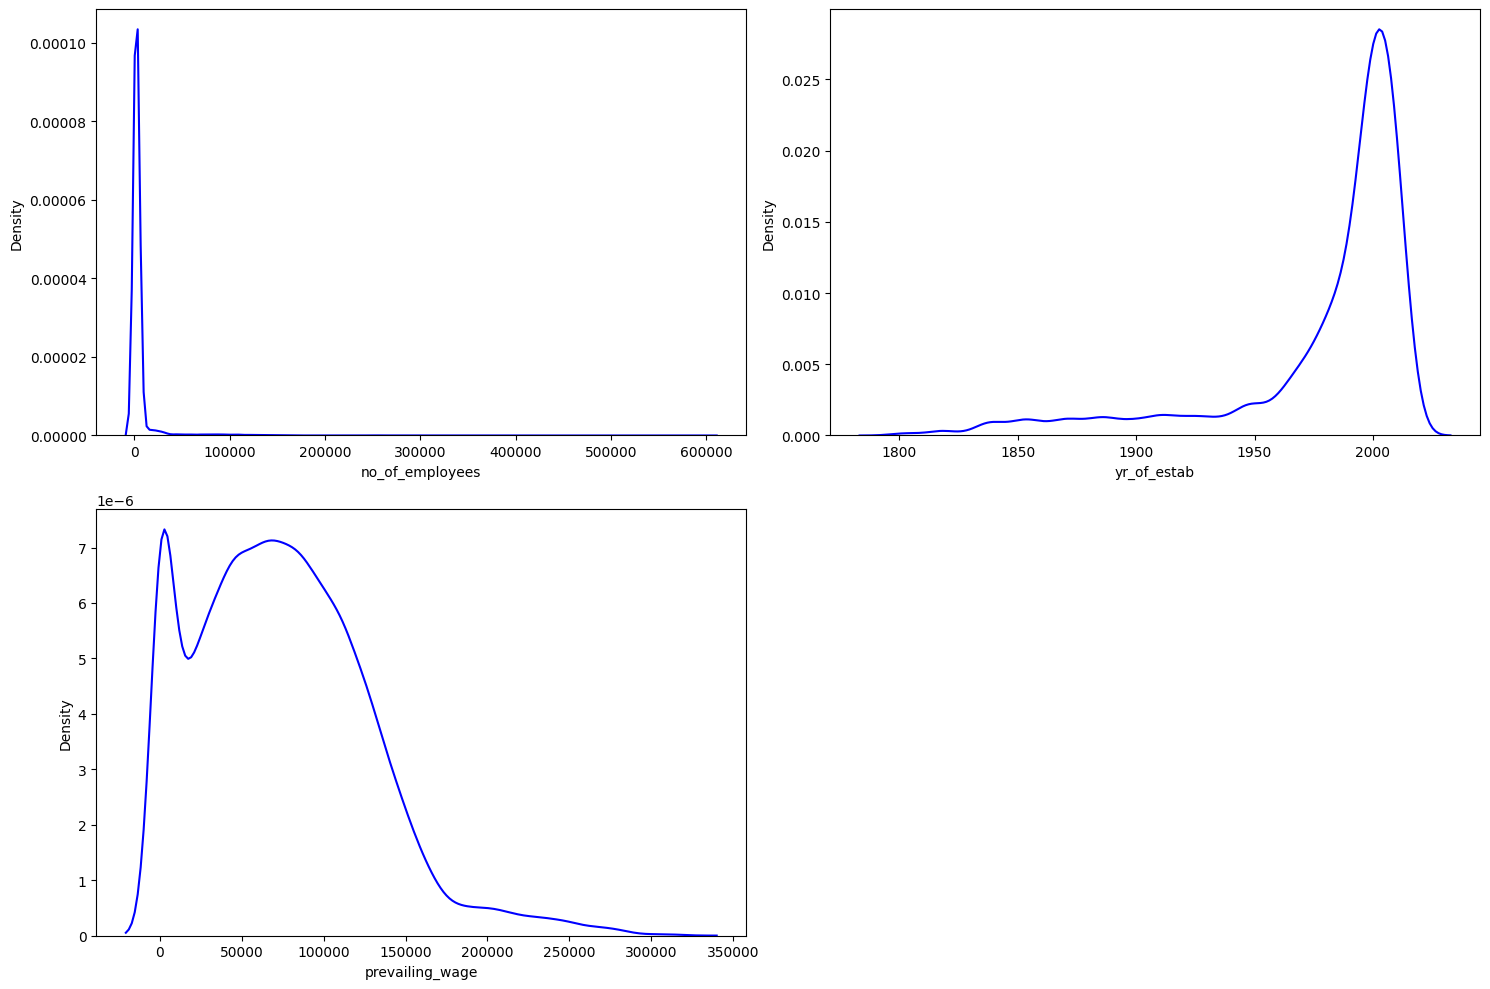

In [17]:
plt.figure(figsize=(15,10))

for i in range(0, len(numerical_features)):
    plt.subplot(2,2,i+1)
    sns.kdeplot(x=df[numerical_features[i]],color='blue')
    plt.xlabel(numerical_features[i])
    plt.tight_layout()



#
- `no_of_cols` : skewed 
- `privaling-wage` : right skewed


In [18]:
    categorical_features

['case_id',
 'continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [19]:
categorical_features.remove('case_id')


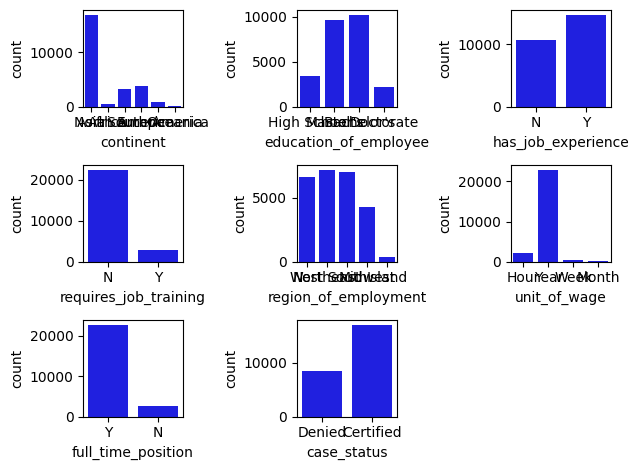

In [20]:
for i in range(0, len(categorical_features)):
    plt.subplot(3,3,i+1)
    sns.countplot(x=df[categorical_features[i]],color='blue')
    plt.xlabel(categorical_features[i])
    plt.tight_layout()


- `requires_job_training` ,`unit_of_wage` , `full_time_position` and `continent` has single category most demand 

# multivariate Analysis 
is the analysis of more than one variable.

In [21]:
discrete_features = [feature for feature in numerical_features if len(df[feature].unique())<=25 ]
continous_features = [feature for feature in numerical_features if len(df[feature].unique()) > 25 ]
print('we have {} discrete features'.format(len(discrete_features) ))
print('we have {} continous features'.format(len(continous_features) ))


we have 0 discrete features
we have 3 continous features


In [22]:
 df.isna().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

## chi square test

In [23]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [26]:
from scipy.stats import chi2_contingency
chi2_test = []

for feature in categorical_features:
    if chi2_contingency(pd.crosstab(df['case_status'],df[feature]))[1] < 0.05:
        chi2_test.append("Reject Null Hypothsesis")
    else:
        chi2_test.append("fail to Reject Null Hypothsesis")

res =pd.DataFrame(data=[categorical_features,chi2_test]).T
res.columns = ['column','Hypothesis Result']
res



,column,Hypothesis Result
0,continent,Reject Null Hypothsesis
1,education_of_employee,Reject Null Hypothsesis
2,has_job_experience,Reject Null Hypothsesis
3,requires_job_training,fail to Reject Null Hypothsesis
4,region_of_employment,Reject Null Hypothsesis
5,unit_of_wage,Reject Null Hypothsesis
6,full_time_position,Reject Null Hypothsesis
7,case_status,Reject Null Hypothsesis


- `requires_job_training` means it doesn't correlate to the target column 

# Nulls checking

In [27]:
df.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [28]:
# Boxplot for outliers

In [35]:
df['case_status'].nunique() ,df['case_status'].value_counts()


(2,
 case_status
 Certified    17018
 Denied        8462
 Name: count, dtype: int64)

In [38]:
counts =df['case_status'].value_counts()

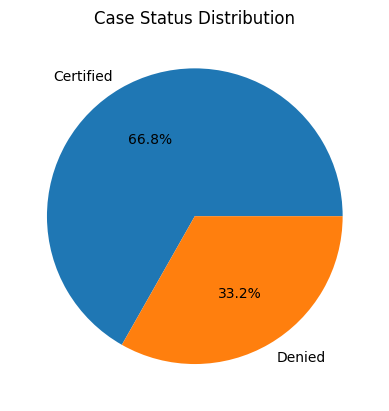

In [40]:
plt.figure()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title('Case Status Distribution')
plt.show()

## insight
#### imbalance data

In [41]:
df.groupby('continent')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
continent     case_status            
Africa        Certified     72.050817
              Denied        27.949183
Asia          Certified     65.310480
              Denied        34.689520
Europe        Certified     79.233655
              Denied        20.766345
North America Certified     61.877278
              Denied        38.122722
Oceania       Certified     63.541667
              Denied        36.458333
South America Certified     57.863850
              Denied        42.136150

<Figure size 640x480 with 0 Axes>

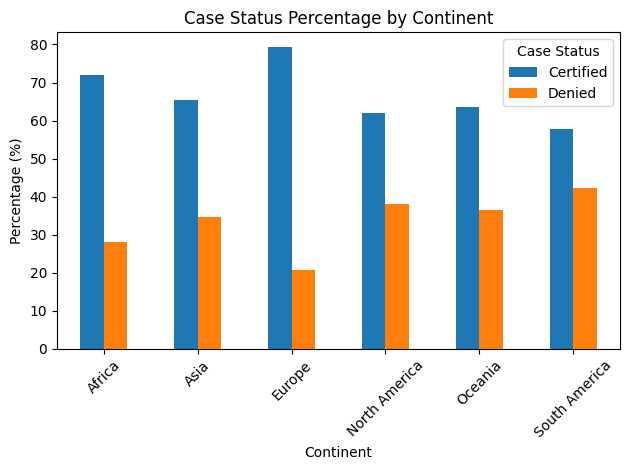

In [43]:
import matplotlib.pyplot as plt

data = (
    df.groupby('continent')['case_status']
      .value_counts(normalize=True)
      .unstack() * 100
)

plt.figure()
data.plot(kind='bar')

plt.title('Case Status Percentage by Continent')
plt.xlabel('Continent')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Case Status')
plt.tight_layout()
plt.show()


## Insight 
Asia has most applicatios

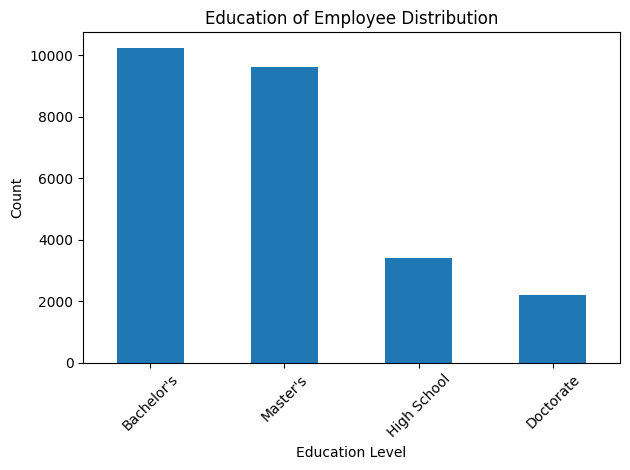

In [46]:
import matplotlib.pyplot as plt

counts = df['education_of_employee'].value_counts()

plt.figure()
counts.plot(kind='bar')

plt.title('Education of Employee Distribution')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Insight 
#### most of them are having Bachelor's degree